In [4]:
# Confirming Python version is greater than or equal to 3.10
import sys
print(sys.version)


3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [5]:
# Importing libaries needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [6]:
# Dataset is directly loaded into Colab and displays the shape & column names
FILE_PATH = 'EmergencyTriageDataset_Reduced_Dirty.csv'
df_raw = pd.read_csv(FILE_PATH)

# Display dataset information
print('Dataset successfully loaded!')
print(f'Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns') #dataset size check
print(f'Columns: {list(df_raw.columns)}') #confirm structure

Dataset successfully loaded!
Shape: 2205 rows x 11 columns
Columns: ['ID', 'Age', 'Gender', 'GCS', 'SBP', 'DBP', 'MAP', 'pulse', 'Temp', 'RR', 'Fio2']


**Age Vs Respiratory Rate**
1) Do patients aged 18 and older fall within the adult normal respiratory rate range (12-20 breaths/min), and how do deviations indicate pathology?
2) A scatterplot is best for this as it shows the spread of individual patient data and the overall trend with age.
3) A regression line shows the overall downward trend in respiratory rate with age and a shaded band between 12-20 for individuals 18 years old and older.

In [7]:
# Respiratory Rate (RR) Cleaning

COLUMN = 'RR'   # RR = Respiratory Rate (breaths per minute)
VALID_MIN = 5            # clinically plausible min RR
VALID_MAX = 60          # clinically plausible max RR

# Converting to numeric
df_raw[COLUMN] = pd.to_numeric(df_raw[COLUMN], errors='coerce') # force numberic, invalid -> NaN

# Range filtering
invalid = df_raw[(df_raw[COLUMN] < VALID_MIN) | (df_raw[COLUMN] > VALID_MAX)] # detect invalid clinical values
df_raw.loc[(df_raw[COLUMN] < VALID_MIN) | (df_raw[COLUMN] > VALID_MAX), COLUMN] = np.nan

# Imputing the data
impute_value = df_raw[COLUMN].median()
(df_raw[COLUMN] < VALID_MIN) | (df_raw[COLUMN] > VALID_MAX)

df_raw.loc[(df_raw[COLUMN] < VALID_MIN) | (df_raw[COLUMN] > VALID_MAX), COLUMN] = np.nan



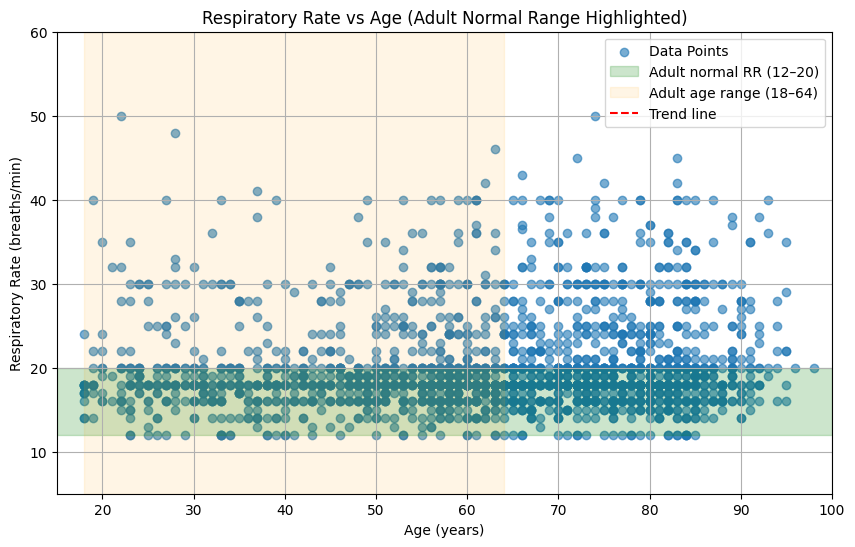

In [8]:
# Scatter plot: RR vs Age
plt.figure(figsize=(10, 6))

# Scatter Plot of Respiratory Rate vs Age
plt.scatter(df_raw['Age'], df_raw[COLUMN], alpha=0.6, label='Data Points')

# Set y-axis and x-axis limits to the safe zone
plt.ylim(VALID_MIN, VALID_MAX)
plt.xlim(15, 100)

# Adding a shaded band for adult normal range (12–20 breaths/min, age ≥18)
plt.axhspan(12, 20, color='green', alpha=0.2, label='Adult normal RR (12–20)')
plt.axvspan(18, 64, color='orange', alpha=0.1, label='Adult age range (18–64)')

# Regression line to show overall trend
z = np.polyfit(df_raw['Age'], df_raw[COLUMN], 1)
p = np.poly1d(z)
plt.plot(df_raw['Age'], p(df_raw['Age']), "r--", label='Trend line')

# Adding labels and title
plt.xlabel("Age (years)")
plt.ylabel("Respiratory Rate (breaths/min)")
plt.title("Respiratory Rate vs Age (Adult Normal Range Highlighted)")
plt.legend(loc='upper right')
plt.grid(True)
plt.savefig('scatter_plot_rr_vs_age.png', dpi=100, bbox_inches='tight') # Saves Scatter Plot as a PNG
plt.show()



**Temperature**
1) What portion of patients present with hypothermia, normal temperature or a fever?
2) A bar chart is best for the categorical proportions


In [9]:
# Using the cleaning code from Tutorial 3 for Temperature

# Temp
def to_celsius(val):
    if pd.isnull(val): return np.nan
    s = str(val).strip()
    try:
        if s.endswith('C'): return float(s[:-1])
        elif s.endswith('F'): return (float(s[:-1]) - 32) * 5/9
        else: return float(s)
    except: return np.nan

df_raw['Temp'] = df_raw['Temp'].apply(to_celsius)
df_raw.loc[(df_raw['Temp'] < 32) | (df_raw['Temp'] > 43), 'Temp'] = np.nan
df_raw['Temp'] = df_raw['Temp'].fillna(df_raw['Temp'].median())


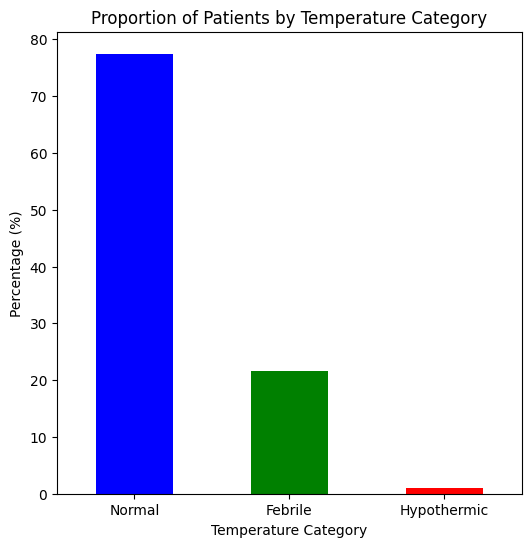

In [10]:
# ── Clinical thresholds ─────────────────────────────
# Hypothermia: < 36.0 °C
# Normal: 36.0–37.5 °C
# Febrile: ≥ 37.6 °C

# Function for the classification of Temperature
def classify_temp(temp):
    if temp < 36.0:
        return 'Hypothermic'
    elif temp <= 37.5:
        return 'Normal'
    else:
        return 'Febrile'

# Applying classification
df_raw['TempCategory'] = df_raw['Temp'].apply(classify_temp)

# Calculating proportions
proportions = df_raw['TempCategory'].value_counts(normalize=True) * 100

# Visualisation of the bar graph
plt.figure(figsize=(6,6))
proportions.plot(kind='bar', color=['blue','green','red'])
plt.title("Proportion of Patients by Temperature Category")
plt.ylabel("Percentage (%)")
plt.xlabel("Temperature Category")
plt.xticks(rotation=0)
plt.savefig('temperature_bar_graph.png', dpi=100, bbox_inches='tight') # Saves the graph as a PNG
plt.show()
